# Calogero-Sutherland model in a harmonic trap (1D)

`N` particles on a line, harmonically trapped, interacting through the inverse-square
Calogero-Sutherland potential. In the code convention $\hbar^2/m = 1$ (kinetic
$=-\sum_i\partial_i^2$, **not** $-\tfrac12\partial_i^2$):

$$ H = -\sum_i \frac{\partial^2}{\partial x_i^2} + \sum_i x_i^2 + 2L(L-1)\sum_{i<j}\frac{1}{(x_i-x_j)^2} $$

**Exact ground state** (Calogero):

$$ \psi_0(x) = C \prod_{i<j}|x_i-x_j|^{L}\,\exp\!\Big(-\tfrac12\sum_i x_i^2\Big),\qquad \log|\psi_0| = L\sum_{i<j}\log|x_i-x_j| - \tfrac12\sum_i x_i^2 $$

**Exact energy** (in this $\omega=1$ convention):
$$ E_0 = N\big(1 + L(N-1)\big), \qquad E_0/N = 1 + L(N-1). $$

This is the CS analogue of the `soft_sphere_gas` notebook: a **parametrised setup** that
builds the `CalogeroSutherlandHamiltonian`, trains an ansatz, and wraps everything in
`run_cs(...)` so you can scan the coupling `L` (or `N`) and compare against the exact $E_0$.

All machinery lives in `qvarnet`:
`qvarnet.hamiltonian.continuous.CalogeroSutherlandHamiltonian`,
`qvarnet.models.analytic.CalogeroSutherlandAnalyticModel`, and `LogJastrow`.

## Imports

In [2]:
%matplotlib inline

In [3]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
import flax.linen as nn

from qvarnet.train import train
from qvarnet.config.training_setup import TrainingConfig, ChainInitAndWarmupConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.geometry.qgt import QGTConfig
from qvarnet.boundaries import NoBoundary
from qvarnet.models.compose import LogWavefunction
from qvarnet.models.mlp import MLP
from qvarnet.models.envelopes import GaussianEnvelope
from qvarnet.models.jastrow import LogJastrow
from qvarnet.models.analytic import CalogeroSutherlandAnalyticModel
from qvarnet.hamiltonian.continuous import CalogeroSutherlandHamiltonian
from qvarnet.callbacks import SnapshotCallback

## 0. Parameters

`L` is the CS coupling (the exact Jastrow exponent $\lambda = L$). `L>1` is repulsive,
`L<1` attractive (and harder). The interaction strength is $g = 2L(L-1)$.

In [4]:
N      = 30          # number of particles
N_DIM  = 1          # CS is a 1-D model
L      = 0.8        # CS coupling (THE scan knob); exact lambda = L
EPS    = 1e-12      # softens the 1/(x_i-x_j)^2 singularity (small but nonzero)

DoF = N * N_DIM
E_exact_total = N * (1 + L * (N - 1))          # code convention, omega=1
E_exact_per_n = E_exact_total / N
print(f'N={N}, L={L}  ->  g = 2L(L-1) = {2*L*(L-1):.3f}')
print(f'Exact E0 = {E_exact_total:.4f}   (E0/N = {E_exact_per_n:.4f})')

N=30, L=0.8  ->  g = 2L(L-1) = -0.320
Exact E0 = 726.0000   (E0/N = 24.2000)


## 1. Ansatz and Hamiltonian

Two ready options:

- **Analytic** (`CalogeroSutherlandAnalyticModel`): the exact log-$\psi$ with a single learnable
  $\lambda$. Converges to the exact energy — the validation baseline.
- **MLP + Gaussian envelope + Jastrow**: a flexible NN ansatz (`LogWavefunction`). The `LogJastrow`
  supplies the $\lambda\sum_{i<j}\log|x_i-x_j|$ cusp that the smooth MLP cannot represent.

`CalogeroSutherlandHamiltonian(L=L, epsilon=EPS)` supplies the kinetic + trap + inverse-square
interaction (the factor-of-2 conventions are handled inside).

In [5]:
LAMBDA_INIT = 1.2   # starting guess for the Jastrow exponent; should drift toward L



class NoNetwork(nn.Module):
    """Network that contributes nothing to log|ψ|: returns zeros of shape (..., 1).

    LogWavefunction sums network + envelope + jastrow, each expected as (..., 1).
    Returning x (shape (..., N)) would broadcast log|ψ| to a vector AND inject the
    raw coordinates into the wavefunction. A constant 0 leaves only envelope+jastrow.
    """
    @nn.compact
    def __call__(self, x):
        return jnp.zeros((*x.shape[:-1], 1))

def make_model(kind='mlp_jastrow', lambda_init=LAMBDA_INIT):
    if kind == 'analytic':
        return CalogeroSutherlandAnalyticModel(lambda_init=lambda_init)
    if kind == 'mlp_jastrow':
        return LogWavefunction(
            transform=NoBoundary(),
            network=MLP(hidden=[128]),
            envelope=GaussianEnvelope(),
            jastrow=LogJastrow(n_particles=N, lambda_init=lambda_init),
        )
    if kind == 'mlp':
        return LogWavefunction(
            transform=NoBoundary(),
            network=MLP(hidden=[64]),
            envelope=GaussianEnvelope(),
        )
    if kind == 'jastrow':

        return LogWavefunction(
            transform=NoBoundary(),
            envelope=GaussianEnvelope(),
            jastrow=LogJastrow(n_particles=N, lambda_init=lambda_init),
            network=NoNetwork(),
        )
    raise ValueError(kind)

def make_hamiltonian(L, eps=EPS):
    return CalogeroSutherlandHamiltonian(L=L, epsilon=eps)

## 2. Train

Open-boundary Metropolis sampler (the trap confines the walkers). `run_cs(...)` is the unit of a
parameter study — **all knobs are explicit in the cell below**; this function is the single
source of truth for how a CS run is configured.

- Default: Adam — the robust exploratory phase (per-parameter update bound ~lr, survives the
  heavy-tailed $1/r^2$ local-energy spikes).
- `use_qgt=True`: stochastic reconfiguration. SR is a *preconditioner* — the optimizer you pass
  is the update rule (`sgd(sr_lr)` = classic SR; pass `optimizer=optax.adam(1e-3)` for
  SR-preconditioned Adam, which beat classic SR in the 2026-07-11 probe). The spike guard is
  the **Fisher trust region** `max_state_change` (state change per step, any lr). No Euclidean
  grad clipping — a clip re-throttles the trust-approved step ~300× and SR stops descending.

`prev_result=...` warm-restarts: best params, final walker positions and the adapted MH step
size carry over (a cold rerun resets the step to 0.5 → ~1% acceptance on a converged
$|\psi|^2$).

In [6]:
def run_cs(L, N=N, kind='mlp_jastrow', n_epochs=20_000, n_chains=4096,
           lr=1e-2, lambda_init=LAMBDA_INIT, seed=0, prev_result=None,
           optimizer=None, use_qgt=False, max_state_change=0.1, sr_lr=1e-3, ratio_proposal=0.1):
    '''Train the CS model at coupling L. Every knob is explicit here.

    prev_result warm-restarts (best params + final walkers + adapted MH step).
    use_qgt=True: SR preconditions the gradient; the optimizer stays the update
    rule (default sgd(sr_lr) = classic SR).
    '''
    E0 = N * (1 + L * (N - 1))
    print(f'Running CS: N={N}, L={L}, model={kind}, SR={use_qgt}  (exact E0={E0:.4f})')

    if optimizer is None:
        optimizer = optax.sgd(sr_lr) if use_qgt else optax.adam(lr)

    warm = prev_result is not None
    return train(
        shape=(n_chains, N * N_DIM), model=make_model(kind, lambda_init),
        hamiltonian=make_hamiltonian(L), coord_mode=LabCoords(),
        optimizer=optimizer,
        init_params=prev_result.best_params() if warm else None,
        training_config=TrainingConfig(
            n_epochs=n_epochs, rng_seed=seed,
            warm_walkers=True, is_update_step_size=True,
            use_qgt=use_qgt, checkpoint_path='./checkpoints/cs'),
        # Fisher trust region: state change per step ≤ max_state_change.
        # Exact semantics when the optimizer is sgd(sr_lr) — keep sr_lr in sync.
        qgt_config=QGTConfig(solver='auto', learning_rate=sr_lr,
                             regularization=1e-2,
                             max_state_change=max_state_change),
        sampler_params={
            'step_size': prev_result.final_step_size if warm else 0.5,
            'chain_length': 21, 'thermalization_steps': 20, 'thinning_factor': 1,
            'proposal': ('particle-subset', {'n_move': int(N * ratio_proposal)}),  # ~2× mixing at N=30
        },
        initial_chain_config=ChainInitAndWarmupConfig(
            init_positions=prev_result.final_positions if warm else 'normal',
            init_position_params={'mean': 0.0, 'std': 0.5},
            warmup_steps=100 if warm else 300,
            warmup_adapt_step_size=True),
        # policy="all": keep per-epoch grads/params for the diagnostics cells below
        callbacks=[SnapshotCallback(policy='all', k=n_epochs, metric='std')],
    )

In [25]:
result = run_cs(L, n_epochs=20_000, lr=1e-2, ratio_proposal=0.1)

Running CS: N=30, L=0.8, model=mlp_jastrow, SR=False  (exact E0=726.0000)


  0%|          | 0/20000 [00:00<?, ?it/s]

100%|██████████| 20000/20000 [02:15<00:00, 148.13it/s, E=726.0002, sigma_E=0.1187]   


── training summary ────────────────────────────────────────
epochs ran       : 20000   (1m 58.9s wall, 4099 parameters)
final epoch      : E = 726.051636 ± 2.09e-02   σ_E = 1.3365
best epoch ( 8886) : E = 726.000000 ± 4.51e-05   σ_E = 0.0029
acceptance (tail): 0.500
best snapshot    : epoch 8886 (select metric = 0.00288667; 20000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────


In [22]:
ratios = [0.05, 0.1, 0.2, 0.5, 0.7, 1.0]
# seeds = [0, 1, 2, 3, 4]
seeds = [0,1]  # for now, just one seed to save time
npartis = 50
ratios = [0.1, 0.5, 1.0]
results = []
for r in ratios:
    for seed in seeds:
        curr_res = run_cs(L, n_epochs=20_000, lr=1e-2, ratio_proposal=r, seed=seed, N=npartis)
        results.append(curr_res)

Running CS: N=50, L=0.8, model=mlp_jastrow, SR=False  (exact E0=2010.0000)


100%|██████████| 20000/20000 [06:26<00:00, 51.80it/s, E=2010.4229, sigma_E=7.5298]             


── training summary ────────────────────────────────────────
epochs ran       : 20000   (6m 09.5s wall, 6659 parameters)
final epoch      : E = 2010.321777 ± 1.29e-01   σ_E = 8.2631
best epoch (19828) : E = 2010.623169 ± 1.14e-01   σ_E = 7.3215
acceptance (tail): 0.499
best snapshot    : epoch 19828 (select metric = 7.32149; 20000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────
Running CS: N=50, L=0.8, model=mlp_jastrow, SR=False  (exact E0=2010.0000)


100%|██████████| 20000/20000 [06:28<00:00, 51.51it/s, E=2009.9893, sigma_E=1.1175]          


── training summary ────────────────────────────────────────
epochs ran       : 20000   (6m 11.6s wall, 6659 parameters)
final epoch      : E = 2010.014160 ± 1.74e-02   σ_E = 1.1134
best epoch (19965) : E = 2010.035889 ± 1.65e-02   σ_E = 1.0533
acceptance (tail): 0.500
best snapshot    : epoch 19965 (select metric = 1.05327; 20000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────
Running CS: N=50, L=0.8, model=mlp_jastrow, SR=False  (exact E0=2010.0000)


...

── training summary ────────────────────────────────────────
epochs ran       : 20000   (6m 12.0s wall, 6659 parameters)
final epoch      : E = 3062.076660 ± 7.55e+01   σ_E = 4833.5054
best epoch (19950) : E = 2942.431641 ± 7.52e+00   σ_E = 481.5698
acceptance (tail): 0.500
best snapshot    : epoch 19950 (select metric = 481.57; 20000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────
Running CS: N=50, L=0.8, model=mlp_jastrow, SR=False  (exact E0=2010.0000)


100%|██████████| 20000/20000 [06:28<00:00, 51.47it/s, E=2018.2854, sigma_E=116.9872]     


── training summary ────────────────────────────────────────
epochs ran       : 20000   (6m 11.6s wall, 6659 parameters)
final epoch      : E = 2020.702393 ± 1.08e+00   σ_E = 68.8035
best epoch (17727) : E = 2024.729248 ± 2.87e-01   σ_E = 18.3559
acceptance (tail): 0.500
best snapshot    : epoch 17727 (select metric = 18.3559; 20000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────
Running CS: N=50, L=0.8, model=mlp_jastrow, SR=False  (exact E0=2010.0000)


100%|██████████| 20000/20000 [06:32<00:00, 51.01it/s, E=2012.6178, sigma_E=19.4853]       


── training summary ────────────────────────────────────────
epochs ran       : 20000   (6m 14.7s wall, 6659 parameters)
final epoch      : E = 2012.234497 ± 3.19e-01   σ_E = 20.4422
best epoch (18507) : E = 2011.818359 ± 2.79e-01   σ_E = 17.8722
acceptance (tail): 0.500
best snapshot    : epoch 18507 (select metric = 17.8722; 20000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────


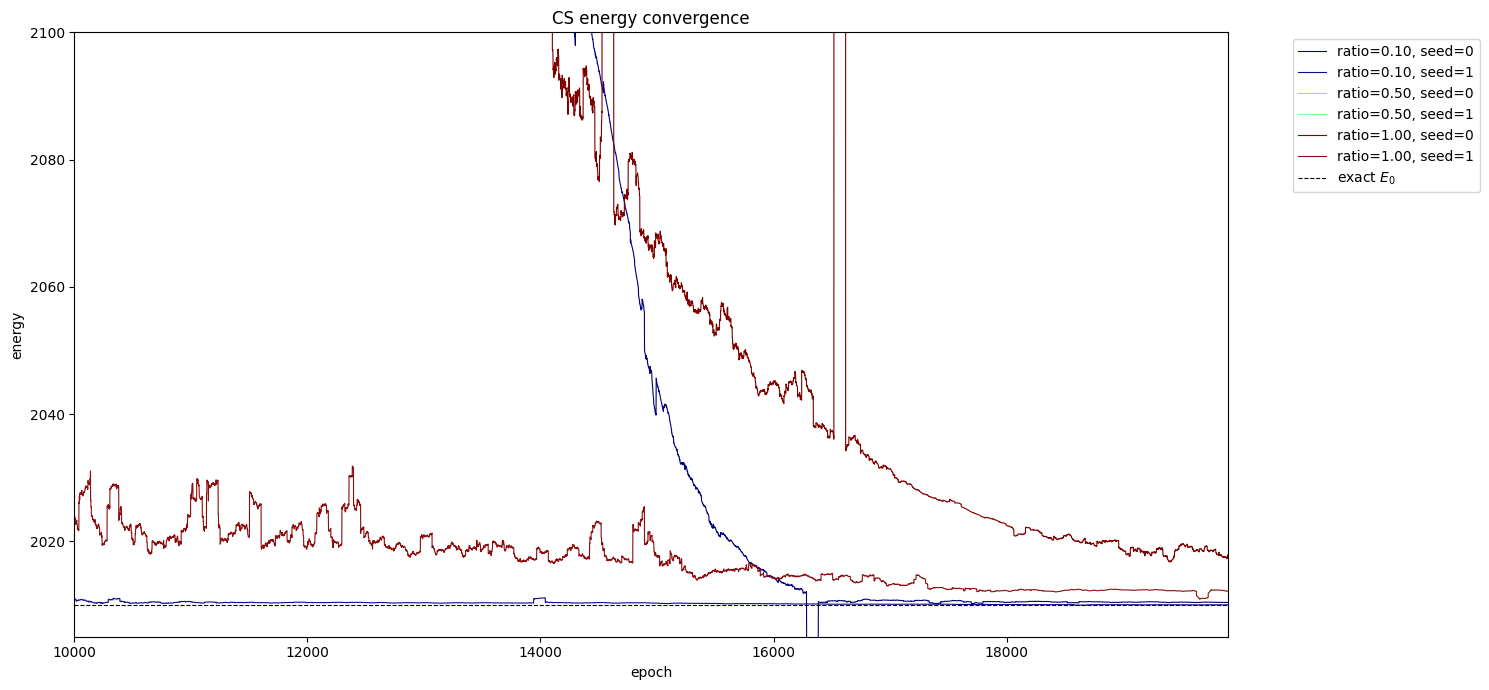

In [43]:
plt.figure(figsize=(15, 7)) 
colors = plt.cm.jet(np.linspace(0, 1, len(ratios)))
mini_color_displacement = 0.05
for r, curr_res in zip(ratios, results):
    for s in seeds:
        color = colors[ratios.index(r)] + mini_color_displacement * seeds.index(s)
        color = np.clip(color, 0, 1)
        curr_res = results[ratios.index(r) * len(seeds) + seeds.index(s)]
        label = f'ratio={r:.2f}, seed={s}'
        energies = np.array([float(s.energy) for s in curr_res.history])
        std_energies = np.array([float(s.std) for s in curr_res.history])
        window = 100
        energies = np.convolve(energies, np.ones(window)/window, mode='valid')
        std_energies = np.convolve(std_energies, np.ones(window)/window, mode='valid')
        plt.plot(energies, lw=0.8, label=label, color=color)
        # plt.fill_between(range(len(energies)), energies - std_energies, energies + std_energies, alpha=0.2)
Eexact = npartis * (1 + L * (npartis - 1))
plt.ylim(bottom = Eexact - 5, top = 2100)
min = 10000 if len(energies) > 10000 else 0
plt.xlim(min, len(energies))
plt.axhline(Eexact, color='k', ls='--', lw=0.8, label='exact $E_0$')
plt.xlabel('epoch'); plt.ylabel('energy'); plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');
plt.title('CS energy convergence'); plt.tight_layout(); plt.show()

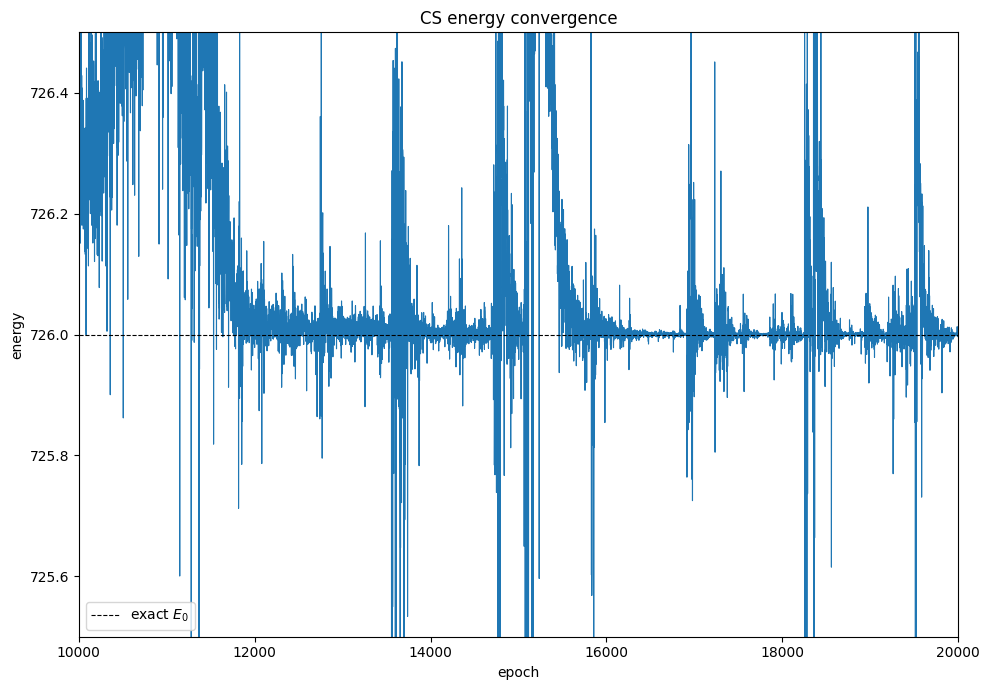

In [7]:
energies = np.array([float(s.energy) for s in result.history])
plt.figure(figsize=(10, 7))
plt.plot(energies, lw=0.8)
plt.ylim(E_exact_total - 0.5, E_exact_total + 0.5)
min = 10000 if len(energies) > 10000 else 0
plt.xlim(min, len(energies))
plt.axhline(E_exact_total, color='k', ls='--', lw=0.8, label='exact $E_0$')
plt.xlabel('epoch'); plt.ylabel('energy'); plt.legend()
plt.title('CS energy convergence'); plt.tight_layout(); plt.show()

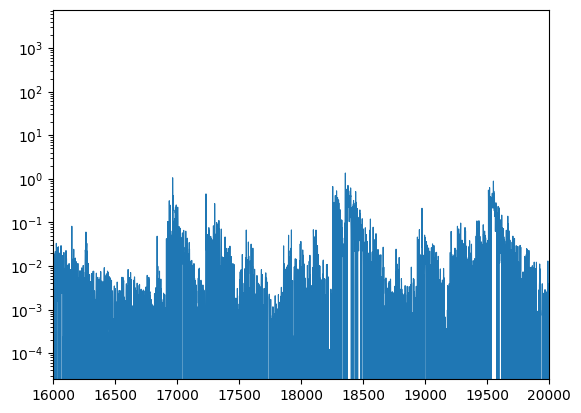

In [8]:
plt.plot(energies-E_exact_total, lw=0.8)
min = 16000 if len(energies) > 16_000 else 0
plt.xlim(min, len(energies))
plt.semilogy()
plt.show()

In [20]:
# SR finetune of the Adam run: warm restart (best params + walkers + adapted step),
# classic SR update rule sgd(sr_lr). For SR-preconditioned Adam (probe winner):
# run_cs(L, use_qgt=True, prev_result=result, optimizer=optax.adam(1e-3), ...)
result_rerun = run_cs(L, use_qgt=True, prev_result=result, n_epochs=2_000)

Running CS: N=30, L=0.8, model=mlp_jastrow, SR=True  (exact E0=726.0000)


100%|██████████| 2000/2000 [00:50<00:00, 39.90it/s, E=726.1685, sigma_E=3.8700]


── training summary ────────────────────────────────────────
epochs ran       : 2000   (0m 47.7s wall, 4099 parameters)
final epoch      : E = 726.105957 ± 5.73e-02   σ_E = 3.6690
best epoch (  739) : E = 725.999512 ± 3.46e-04   σ_E = 0.0222
acceptance (tail): 0.500
best snapshot    : epoch 739 (select metric = 0.0221726; 2000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────


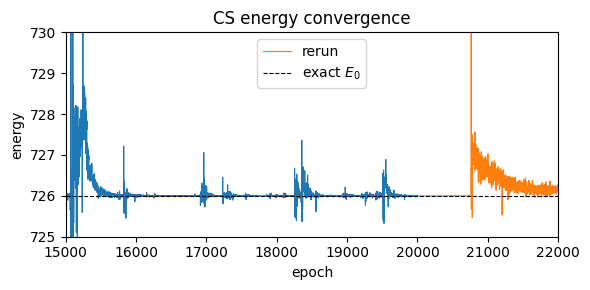

In [21]:
energies = np.array([float(s.energy) for s in result.history])
epochs = np.arange(len(energies))
plt.figure(figsize=(6, 3))
plt.plot(epochs, energies, lw=0.8)
energies_rerun = np.array([float(s.energy) for s in result_rerun.history])
epochs_rerun = np.arange(len(energies_rerun)) + len(energies)
plt.plot(epochs_rerun, energies_rerun, lw=0.8, label='rerun')
plt.axhline(E_exact_total, color='k', ls='--', lw=0.8, label='exact $E_0$')
plt.xlabel('epoch'); plt.ylabel('energy'); plt.legend()
plt.ylim(725, 730); plt.xlim(15000 if len(energies) > 15000 else 0, len(energies) + len(energies_rerun))
plt.title('CS energy convergence'); plt.tight_layout(); plt.show()

In [22]:
result_rerun = run_cs(L, prev_result=result, n_epochs=2_000, use_qgt=False, optimizer=optax.adam(1e-2))

Running CS: N=30, L=0.8, model=mlp_jastrow, SR=False  (exact E0=726.0000)


100%|██████████| 2000/2000 [00:16<00:00, 121.12it/s, E=726.0001, sigma_E=0.0700] 


── training summary ────────────────────────────────────────
epochs ran       : 2000   (0m 14.3s wall, 4099 parameters)
final epoch      : E = 726.000183 ± 2.20e-04   σ_E = 0.0141
best epoch ( 1885) : E = 725.999939 ± 1.18e-04   σ_E = 0.0076
acceptance (tail): 0.500
best snapshot    : epoch 1885 (select metric = 0.00756068; 2000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────


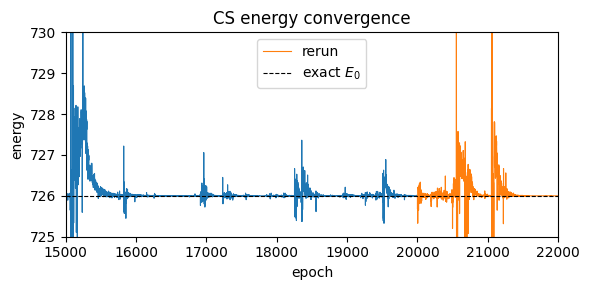

In [23]:
energies = np.array([float(s.energy) for s in result.history])
epochs = np.arange(len(energies))
plt.figure(figsize=(6, 3))
plt.plot(epochs, energies, lw=0.8)
energies_rerun = np.array([float(s.energy) for s in result_rerun.history])
epochs_rerun = np.arange(len(energies_rerun)) + len(energies)
plt.plot(epochs_rerun, energies_rerun, lw=0.8, label='rerun')
plt.axhline(E_exact_total, color='k', ls='--', lw=0.8, label='exact $E_0$')
plt.xlabel('epoch'); plt.ylabel('energy'); plt.legend()
plt.ylim(725, 730); plt.xlim(15000 if len(energies) > 15000 else 0, len(energies) + len(energies_rerun))
plt.title('CS energy convergence'); plt.tight_layout(); plt.show()

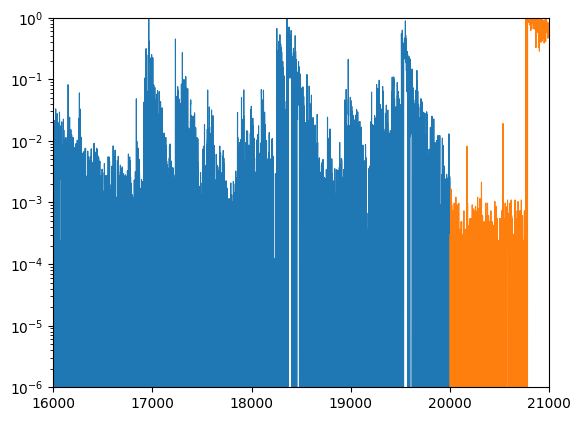

In [11]:
plt.plot(range(len(energies)), energies-E_exact_total, lw=0.8)
plt.plot(range(len(energies), len(energies) + len(energies_rerun)), energies_rerun-E_exact_total, lw=0.8, label='rerun')
plt.xlim(16_000 if len(energies) > 16_000 else 0, len(energies) + len(energies_rerun))
plt.ylim(1e-6, 1e0)
plt.semilogy()
plt.show()

In [12]:
def get_param_statistics(params):
    """Return mean and std of the parameters in a dict."""
    params = params['params']
    lambda_param = params['jastrow']['lambda']
    envelope_params = params['envelope']
    network_params, _ = jax.tree_util.tree_flatten(params["network"])
    network_params = [p.ravel() for p in network_params]
    vec_network_params = np.concatenate([np.array(p) for p in network_params])
    return {"network": {
        'mean': np.mean(vec_network_params),
        'std': np.std(vec_network_params),
        'min': np.min(vec_network_params),
        'max': np.max(vec_network_params),
        'l2_norm': np.linalg.norm(vec_network_params),
    },
            "envelope": {
        'value': {k: f"{float(v):.4f}" for k, v in envelope_params.items()},
    },
            "lambda": {
        'value': f"{float(lambda_param):.4f}",
    }}

def print_param_statistics(stats):
    """Print the parameter statistics in a readable format."""
    for key, value in stats.items():
        print(f"{key}:")
        for subkey, subvalue in value.items():
            if isinstance(subvalue, dict):
                print(f"  {subkey}:")
                for k, v in subvalue.items():
                    print(f"    {k}: {v}")
            else:
                print(f"  {subkey}: {subvalue}")

print(get_param_statistics(result.final_params))
print(get_param_statistics(result_rerun.final_params))

{'network': {'mean': np.float32(0.0061334735), 'std': np.float32(0.6049069), 'min': np.float32(-4.3218365), 'max': np.float32(4.3912163), 'l2_norm': np.float32(38.720757)}, 'envelope': {'value': {'alpha': '0.7071'}}, 'lambda': {'value': '0.8000'}}
{'network': {'mean': np.float32(0.06743103), 'std': np.float32(3.255595), 'min': np.float32(-21.323708), 'max': np.float32(26.162233), 'l2_norm': np.float32(208.42819)}, 'envelope': {'value': {'alpha': '0.7083'}}, 'lambda': {'value': '0.8005'}}


In [13]:
print("Final parameters after first run:")
print_param_statistics(get_param_statistics(result.final_params))
print("Final parameters after rerun:")
print_param_statistics(get_param_statistics(result_rerun.final_params))

Final parameters after first run:
network:
  mean: 0.006133473478257656
  std: 0.6049069166183472
  min: -4.321836471557617
  max: 4.391216278076172
  l2_norm: 38.72075653076172
envelope:
  value:
    alpha: 0.7071
lambda:
  value: 0.8000
Final parameters after rerun:
network:
  mean: 0.06743103265762329
  std: 3.2555949687957764
  min: -21.323707580566406
  max: 26.162233352661133
  l2_norm: 208.42819213867188
envelope:
  value:
    alpha: 0.7083
lambda:
  value: 0.8005


In [14]:
print_param_statistics(get_param_statistics(result.snapshots[-1]["grads"]))

network:
  mean: 1.0708741683629341e-05
  std: 0.0003804026055149734
  min: -0.005323224235326052
  max: 0.006280224304646254
  l2_norm: 0.02435838244855404
envelope:
  value:
    alpha: -0.1970
lambda:
  value: 0.1154


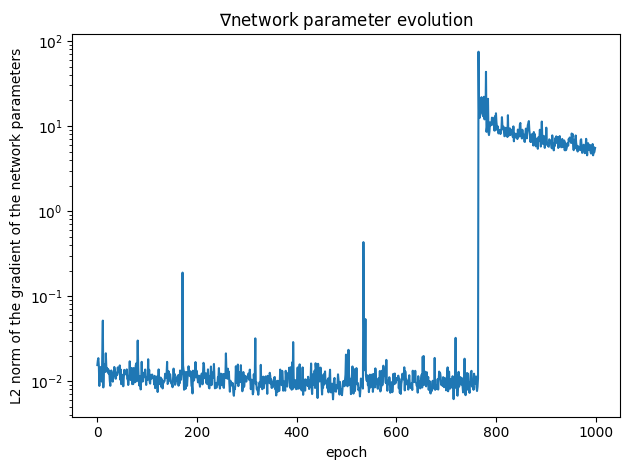

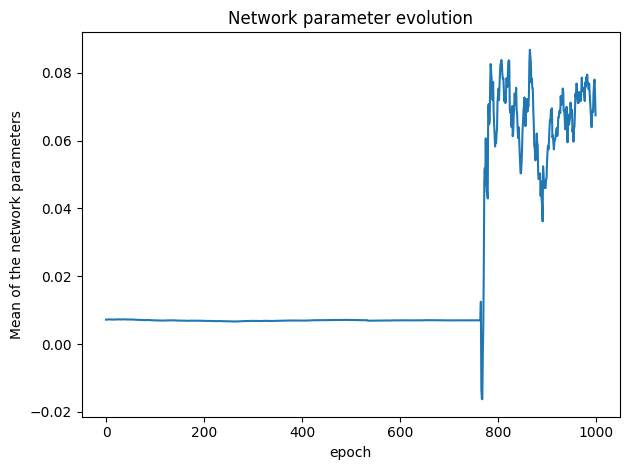

In [15]:
grads_along_learning = np.array([get_param_statistics(s["grads"]) for s in result_rerun.snapshots])
values_along_learning = np.array([get_param_statistics(s["params"]) for s in result_rerun.snapshots])
network_grad_statistics = {
    "mean": np.array([s["network"]["mean"] for s in grads_along_learning]),
    "std": np.array([s["network"]["std"] for s in grads_along_learning]),
    "min": np.array([s["network"]["min"] for s in grads_along_learning]),
    "max": np.array([s["network"]["max"] for s in grads_along_learning]),
    "l2_norm": np.array([s["network"]["l2_norm"] for s in grads_along_learning]),
}
network_param_statistics = {
    "mean": np.array([s["network"]["mean"] for s in values_along_learning]),
    "std": np.array([s["network"]["std"] for s in values_along_learning]),
    "min": np.array([s["network"]["min"] for s in values_along_learning]),
    "max": np.array([s["network"]["max"] for s in values_along_learning]),
    "l2_norm": np.array([s["network"]["l2_norm"] for s in values_along_learning]),
}
plt.plot(network_grad_statistics["l2_norm"])
plt.semilogy()
plt.xlabel('epoch'); plt.ylabel('L2 norm of the gradient of the network parameters'); plt.title(r'$\nabla$network parameter evolution'); plt.tight_layout(); plt.show()
plt.plot(network_param_statistics["mean"])
# plt.fill_between(range(len(network_param_statistics["mean"])),
#                  network_param_statistics["mean"] - network_param_statistics["std"]/np.sqrt(len(network_param_statistics["mean"])),
#                  network_param_statistics["mean"] + network_param_statistics["std"]/np.sqrt(len(network_param_statistics["mean"])),
#                  alpha=0.2)
plt.xlabel('epoch'); plt.ylabel('Mean of the network parameters'); plt.title('Network parameter evolution'); plt.tight_layout(); plt.show()

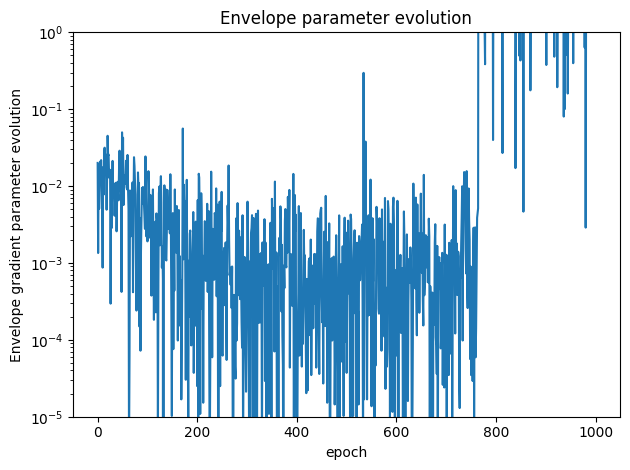

In [16]:
envelope_grad_evol = np.array([float(s["envelope"]["value"]["alpha"])**2 for s in grads_along_learning])
plt.ylim(0.0, 1.0)
plt.plot(envelope_grad_evol)
plt.ylim(1e-5, 1.0)
plt.semilogy()
plt.xlabel('epoch'); plt.ylabel('Envelope gradient parameter evolution'); plt.title('Envelope parameter evolution'); plt.tight_layout(); plt.show()

[]

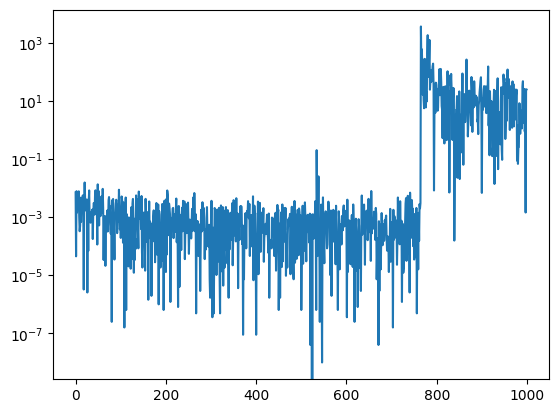

In [17]:
jastrow_grad_evol = np.array([float(s["lambda"]["value"])**2 for s in grads_along_learning])
plt.plot(jastrow_grad_evol)
plt.semilogy()

In [19]:
# SR from scratch — needs the cusp-exact Jastrow init (lambda_init=L). With the cusp
# broken (LAMBDA_INIT=1.2) the 2[λ(λ-1)-L(L-1)]/r² local-energy spikes poison every
# gradient before the optimizer can act. The Fisher trust region (max_state_change)
# rides out remaining spikes; 0.3 descended ~3× faster than 0.1 in the 2026-07-11
# probes (validated for both finetune and scratch).
result_only_with_qgt = run_cs(L, use_qgt=True, n_epochs=5000, lambda_init=L,
                              max_state_change=0.3, optimizer=optax.adam(1e-2), sr_lr=1e-2)

Running CS: N=30, L=0.8, model=mlp_jastrow, SR=True  (exact E0=726.0000)


100%|██████████| 5000/5000 [01:58<00:00, 42.37it/s, E=726.0828, sigma_E=1.0043]    


── training summary ────────────────────────────────────────
epochs ran       : 5000   (1m 53.2s wall, 4099 parameters)
final epoch      : E = 726.044922 ± 3.64e-02   σ_E = 2.3295
best epoch ( 1096) : E = 726.011230 ± 1.04e-02   σ_E = 0.6643
acceptance (tail): 0.500
best snapshot    : epoch 1096 (select metric = 0.664334; 5000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────
